In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
df=pd.read_csv("/content/all-data.csv")

In [ ]:
data=df.copy()

In [ ]:
data.columns

Index(['Sentimant', 'Sentence'], dtype='object')

In [ ]:
from sklearn.model_selection import train_test_split
x=data["Sentence"]
y=data["Sentimant"]

In [ ]:
x_tmp, x_test, y_tmp, y_test = train_test_split(x, y, test_size=0.15, random_state=42, stratify=y)
x_train, x_val, y_train, y_val = train_test_split(x_tmp, y_tmp, test_size=0.1765, random_state=42, stratify=y_tmp)

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_val   = encoder.transform(y_val)
y_test  = encoder.transform(y_test)
print(encoder.classes_, len(x_train), len(x_val), len(x_test))

['negative' 'neutral' 'positive'] 3391 728 727


In [ ]:
import re

def clean_text(text):
    text = text.lower()                                # lowercase
    text = re.sub(r"http\S+|www\S+", " ", text)         # remove links
    text = re.sub(r"[^a-z%\s]", " ", text)              # keep letters + % symbol
    text = re.sub(r"\s+", " ", text)                   # remove extra spaces
    return text.strip()

In [ ]:
X_train_clean = x_train.apply(clean_text)
X_test_clean = x_test.apply(clean_text)
X_val_clean = x_val.apply(clean_text)

In [ ]:
X_train_clean[10::]

,Sentence
3551,cargotec will also move hallberg ivarsson s se...
0,according to gran the company has no plans to ...
4742,in the baltic countries development of operati...
1817,the company s objective is to offer the best p...
846,helsingin uutiset vantaan sanomat and lansivay...
...,...
487,estonia s beer market overall grew three perce...
744,after the share purchase is completed financin...
786,the estimated synergy benefits are at least eu...
40,in january september fiskars net profit went u...


training fast test only on x_train to over come the data leakage problem

In [ ]:
train_tokens = [text.split() for text in X_train_clean]

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 73.5 MB/s eta 0:00:00


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_clean)

Training Fast Test model on x_train data only

In [ ]:
from gensim.models import FastText

fasttext_model = FastText(
    sentences=X_train_clean,   # already tokenized sentences
    vector_size=300,
    window=5,
    min_count=2,
    sg=1,
    epochs=10
)

The embedding matrix store all the vectors of the trained data

In [ ]:
import numpy as np

embedding_dim = 300
word_index = tokenizer.word_index

embedding_matrix = np.zeros((len(word_index) + 1, embedding_dim))

for word, i in word_index.items():
    try:
        embedding_matrix[i] = fasttext_model.wv[word]
    except KeyError:
        pass

In [ ]:
embedding_matrix[1]

array([-1.24492403e-03, -7.93350977e-04, -1.01027304e-04,  3.42973681e-06,
       -5.63922513e-04, -3.82442027e-04, -1.68902698e-04,  7.14165042e-04,
        5.98399376e-04,  7.17594885e-05,  3.48470698e-04, -4.37104987e-04,
        2.79889373e-05, -6.80653902e-04,  3.68425710e-04,  3.95609561e-04,
       -3.72705799e-05, -5.67491516e-04,  1.44507576e-04,  8.63579975e-04,
        1.06696221e-04,  9.52449976e-04,  1.51277651e-04, -9.63943785e-06,
        9.17660189e-04, -3.88056505e-05,  5.73224446e-04, -1.75978916e-04,
        2.32084174e-04, -1.06399413e-04,  1.02437031e-03, -3.92009970e-04,
        7.11709261e-04, -4.07706480e-04, -1.70500687e-04,  5.56639861e-05,
        2.89534219e-04,  2.28437144e-04, -2.28672652e-04,  4.17172938e-04,
        6.71683665e-05,  4.71549574e-05,  5.26943302e-04, -7.08578678e-04,
       -4.11604851e-04, -9.31161776e-05, -6.61063939e-04, -6.13808050e-04,
       -1.14172663e-05,  2.23733616e-04,  7.26040089e-05, -1.30389322e-04,
        1.25966937e-04,  

In [ ]:
print(fasttext_model.wv['profit']) # vector for the word profit of size 300

[ 0.4647758  -0.18070926 -0.04276106 -0.0512696  -0.3536707  -0.26107335
 -0.5374772  -0.10835701  0.37157154  0.37232596 -0.14390187 -0.00728258
 -0.3957277  -0.13806549  0.28200185 -0.01681913  0.3352468   0.10120231
  0.59356654 -0.30488637  0.13965861  0.45743334 -0.01183291 -0.1405382
  0.24087168  0.05478491  0.33651194 -0.10340589 -0.30397883 -0.6390743
  0.2710637   0.5892503   0.0812332  -0.39554313 -0.5668046  -0.3268517
 -0.02009499  0.38012752  0.13010764  0.32872954  0.01362791  0.15552373
  0.12164456 -0.18898214 -0.09832196  0.28484517 -0.38861045  0.6926052
  0.525057    0.28106937  0.32999524 -0.01698757  0.3118401  -0.72650754
 -0.41973972 -0.04292316  0.25166693  0.37202573  0.09752152 -0.52994764
 -0.03227946 -0.48791072 -0.5439664   0.18178132  0.49888766 -0.0448953
 -0.11100765 -0.12661755 -0.14625965 -0.09649565 -0.49683943 -0.23714851
  0.4654054   0.4011675   0.12991634 -0.3236083  -0.6100517   0.6237133
 -0.347637    0.51547545  0.2699486   0.18836613 -0.26348

converting text into numbers using tokenizer

In [ ]:
X_train_seq = tokenizer.texts_to_sequences(X_train_clean)
X_val_seq   = tokenizer.texts_to_sequences(X_val_clean)
X_test_seq  = tokenizer.texts_to_sequences(X_test_clean)

add padding to get all the vectors into same size

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = 100

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_val_pad   = pad_sequences(X_val_seq, maxlen=max_len)
X_test_pad  = pad_sequences(X_test_seq, maxlen=max_len)

Weights are assigned to each class to overcome  class misbalance

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(2.678515007898894), 1: np.float64(0.56095947063689), 2: np.float64(1.1848357791754018)}


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',      # watch validation loss
    patience=4,              # wait 2 epochs before stopping
    restore_best_weights=True
)

**LSTM model**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

model_lstm = Sequential([
    Embedding(
        input_dim=len(word_index) + 1,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=100,   # same as max_len
        trainable=False
    ),
    LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.2),
    LSTM(32, dropout=0.2, recurrent_dropout=0.2),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Embedding, SpatialDropout1D
from tensorflow.keras.optimizers import Adam

model_lstm_optimized = Sequential([

    # Embedding Layer (FastText)
    Embedding(
        input_dim=len(word_index) + 1,
        output_dim=300,
        weights=[embedding_matrix],
        trainable=False   # important to reduce overfitting
    ),

    # Spatial Dropout (your tuner result)
    SpatialDropout1D(0.2),

    # First LSTM Layer
    LSTM(128, return_sequences=True),

    # Dropout
    Dropout(0.4),

    # Second LSTM Layer (reduced size for stability)
    LSTM(64),

    # Dropout
    Dropout(0.4),

    # Dense layers
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

In [ ]:
model_lstm.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history=model_lstm.fit(
    X_train_pad,
    y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_val_pad, y_val),
    class_weight=class_weights,
    #callbacks=[early_stopping],
    verbose=1
)

Epoch 1/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 42s 684ms/step - accuracy: 0.3772 - loss: 1.0994 - val_accuracy: 0.5934 - val_loss: 1.0914
Epoch 2/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 37s 701ms/step - accuracy: 0.3108 - loss: 1.0993 - val_accuracy: 0.2720 - val_loss: 1.0980
Epoch 3/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 41s 699ms/step - accuracy: 0.4158 - loss: 1.0985 - val_accuracy: 0.4093 - val_loss: 1.0992
Epoch 4/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 37s 705ms/step - accuracy: 0.3728 - loss: 1.0990 - val_accuracy: 0.4464 - val_loss: 1.1039
Epoch 5/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 35s 666ms/step - accuracy: 0.3781 - loss: 1.0961 - val_accuracy: 0.4299 - val_loss: 1.1047
Epoch 6/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 41s 663ms/step - accuracy: 0.3996 - loss: 1.0948 - val_accuracy: 0.2321 - val_loss: 1.1179
Epoch 7/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 37s 701ms/step - accuracy: 0.3406 - loss: 1.0929 - val_accuracy: 0.2431 - val_loss: 1.0956
Epoch 8/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 41s 704ms/step - accuracy: 0.4188 - loss: 1.0901 - val_accu

In [ ]:
test_loss, test_acc = model_lstm.evaluate(X_test_pad, y_test)

print("Test Accuracy:", test_acc)

23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step - accuracy: 0.5598 - loss: 1.0300
Test Accuracy: 0.5598349571228027


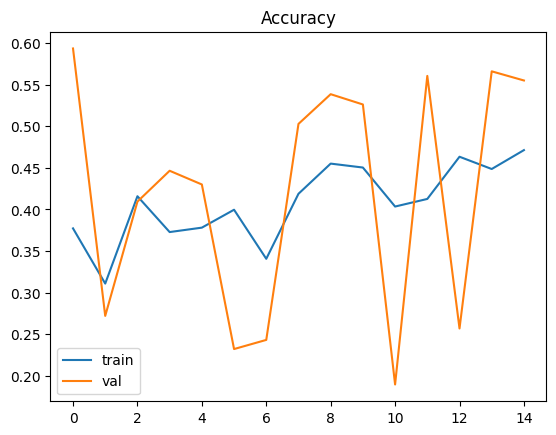

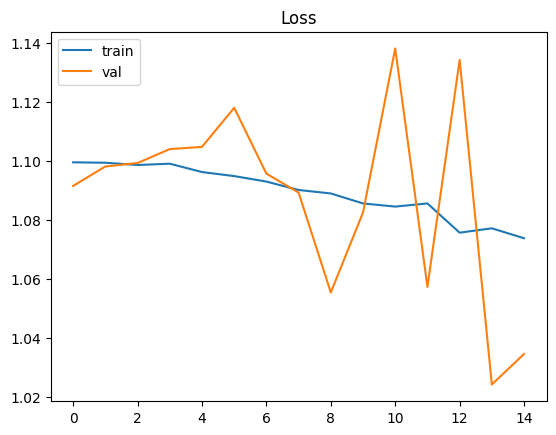

In [ ]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss plot
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.title("Loss")
plt.show()

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

y_pred = np.argmax(model_lstm.predict(X_test_pad), axis=1)

print(classification_report(y_test, y_pred))

23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 174ms/step
              precision    recall  f1-score   support

           0       0.26      0.45      0.33        91
           1       0.64      0.85      0.73       432
           2       0.00      0.00      0.00       204

    accuracy                           0.56       727
   macro avg       0.30      0.43      0.35       727
weighted avg       0.42      0.56      0.48       727



**Bi lstm MOdel**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

model_bilstm = Sequential([
    Embedding(
        input_dim=len(tokenizer.word_index) + 1,
        output_dim=300,
        weights=[embedding_matrix],
        trainable=True
    ),

    Bidirectional(LSTM(64)),

    Dropout(0.5),

    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Embedding, SpatialDropout1D, Bidirectional
from tensorflow.keras.optimizers import Adam

model_bilstm_optimized = Sequential([

    # Embedding Layer (FastText)
    Embedding(
        input_dim=len(word_index) + 1,
        output_dim=300,
        weights=[embedding_matrix],
        trainable=False   # prevents overfitting
    ),

    # Spatial Dropout (from tuner)
    SpatialDropout1D(0.2),

    # First BiLSTM Layer
    Bidirectional(
        LSTM(128, return_sequences=True)
    ),

    Dropout(0.3),

    # Second BiLSTM Layer (reduced units)
    Bidirectional(
        LSTM(64)
    ),

    Dropout(0.3),

    # Dense layers
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, SpatialDropout1D
from tensorflow.keras.optimizers import Adam

model_bilstm_model = Sequential([

    # Embedding Layer (FastText)
    Embedding(
        input_dim=len(tokenizer.word_index) + 1,
        output_dim=300,
        weights=[embedding_matrix],
        trainable=True   #  freeze to avoid overfitting
    ),

    #  Spatial Dropout (important for NLP)
    SpatialDropout1D(0.3),

    #  BiLSTM (based on tuner → 128 units)
    Bidirectional(LSTM(128)),

    #  Strong Dropout
    Dropout(0.5),

    # Dense Layers
    Dense(32, activation='relu'),
    Dropout(0.3),

    Dense(3, activation='softmax')
])

In [ ]:
model_bilstm_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Class Weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=1,
    min_lr=1e-5
)

# Train
history = model_bilstm_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=32,
    class_weight=class_weights,
    #callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 37s 324ms/step - accuracy: 0.4471 - loss: 1.0409 - val_accuracy: 0.6511 - val_loss: 0.8564
Epoch 2/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 37s 349ms/step - accuracy: 0.7358 - loss: 0.6964 - val_accuracy: 0.7170 - val_loss: 0.7214
Epoch 3/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 35s 330ms/step - accuracy: 0.8800 - loss: 0.3565 - val_accuracy: 0.6799 - val_loss: 0.7922
Epoch 4/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 40s 328ms/step - accuracy: 0.9416 - loss: 0.2013 - val_accuracy: 0.7212 - val_loss: 0.8860
Epoch 5/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 42s 341ms/step - accuracy: 0.9676 - loss: 0.1240 - val_accuracy: 0.7363 - val_loss: 1.0820
Epoch 6/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 36s 342ms/step - accuracy: 0.9705 - loss: 0.0998 - val_accuracy: 0.7486 - val_loss: 1.0823
Epoch 7/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 39s 321ms/step - accuracy: 0.9802 - loss: 0.0797 - val_accuracy: 0.7363 - val_loss: 1.0827
Epoch 8/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 35s 329ms/step - accuracy: 0.9855 - loss: 0

In [ ]:
test_loss, test_acc = model_bilstm_model.evaluate(X_test_pad, y_test)

print("Test Accuracy:", test_acc)

23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - accuracy: 0.7290 - loss: 1.3224
Test Accuracy: 0.7290233969688416


In [ ]:
import numpy as np
from sklearn.metrics import classification_report

y_pred = np.argmax(model_bilstm_model.predict(X_test_pad), axis=1)

print(classification_report(y_test, y_pred))

23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 111ms/step
              precision    recall  f1-score   support

           0       0.59      0.63      0.61        91
           1       0.79      0.83      0.81       432
           2       0.66      0.56      0.61       204

    accuracy                           0.73       727
   macro avg       0.68      0.67      0.67       727
weighted avg       0.73      0.73      0.73       727



In [ ]:
model_bilstm.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
history_bilstm=model_bilstm.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val_pad, y_val),
    class_weight=class_weights,
    callbacks=[early_stopping]
)

Epoch 1/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.5777 - loss: 0.9932 - val_accuracy: 0.5934 - val_loss: 0.9099
Epoch 2/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.7411 - loss: 0.6512 - val_accuracy: 0.6951 - val_loss: 0.7366
Epoch 3/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8829 - loss: 0.3441 - val_accuracy: 0.6690 - val_loss: 0.8590
Epoch 4/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9446 - loss: 0.1795 - val_accuracy: 0.6964 - val_loss: 1.0082
Epoch 5/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9743 - loss: 0.0978 - val_accuracy: 0.7363 - val_loss: 1.0163
Epoch 6/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9802 - loss: 0.0737 - val_accuracy: 0.7390 - val_loss: 1.2420


In [ ]:
test_loss, test_acc = model_bilstm.evaluate(X_test_pad, y_test)

print("Test Accuracy:", test_acc)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6946 - loss: 0.7503
Test Accuracy: 0.6946355104446411


In [ ]:
import numpy as np
from sklearn.metrics import classification_report

y_pred = np.argmax(model_bilstm.predict(X_test_pad), axis=1)

print(classification_report(y_test, y_pred))

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
              precision    recall  f1-score   support

           0       0.50      0.75      0.60        91
           1       0.80      0.77      0.78       432
           2       0.60      0.52      0.56       204

    accuracy                           0.69       727
   macro avg       0.63      0.68      0.65       727
weighted avg       0.71      0.69      0.70       727



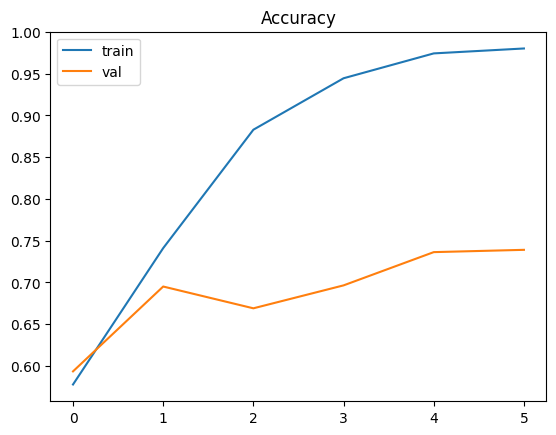

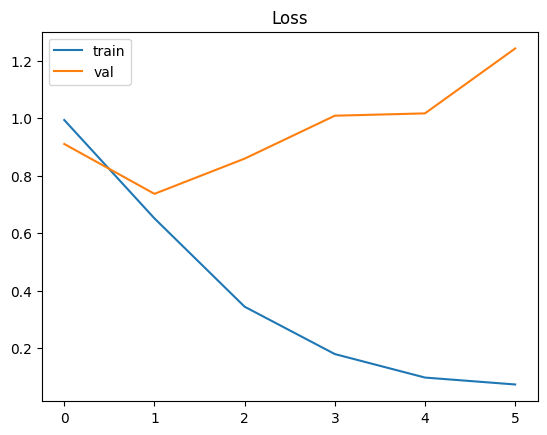

In [ ]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.plot(history_bilstm.history['accuracy'], label='train')
plt.plot(history_bilstm.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss plot
plt.plot(history_bilstm.history['loss'], label='train')
plt.plot(history_bilstm.history['val_loss'], label='val')
plt.legend()
plt.title("Loss")
plt.show()

In [ ]:
from tensorflow.keras.layers import GRU

model_gru = Sequential([
    Embedding(
        input_dim=len(tokenizer.word_index) + 1,
        output_dim=300,
        weights=[embedding_matrix],
        trainable=True
    ),

    GRU(64),

    Dropout(0.5),

    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

In [ ]:
model_gru.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_gru = model_gru.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val_pad, y_val),
    class_weight=class_weights,
    callbacks=[early_stopping]
)

Epoch 1/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5615 - loss: 1.0074 - val_accuracy: 0.5907 - val_loss: 0.8841
Epoch 2/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7490 - loss: 0.6404 - val_accuracy: 0.6552 - val_loss: 0.8670
Epoch 3/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8968 - loss: 0.3153 - val_accuracy: 0.6992 - val_loss: 0.9180
Epoch 4/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9519 - loss: 0.1434 - val_accuracy: 0.7170 - val_loss: 0.9541


In [ ]:
test_loss, test_acc = model_gru.evaluate(X_test_pad, y_test)
print("GRU Test Accuracy:", test_acc)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6080 - loss: 0.8773
GRU Test Accuracy: 0.6079779863357544


GRU model is also over fitting

In [ ]:
y_pred = np.argmax(model_gru.predict(X_test_pad), axis=1)

print(classification_report(y_test, y_pred))

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
              precision    recall  f1-score   support

           0       0.31      0.65      0.42        91
           1       0.74      0.82      0.78       432
           2       0.45      0.13      0.20       204

    accuracy                           0.61       727
   macro avg       0.50      0.53      0.47       727
weighted avg       0.61      0.61      0.57       727



In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

def predict_text(text):
    # preprocess (same as training)
    text = text.lower()

    # convert to sequence
    seq = tokenizer.texts_to_sequences([text])

    # pad
    padded = pad_sequences(seq, maxlen=100)   # use your max_len

    # predict
    pred = model_bilstm_model.predict(padded)
    pred_class = np.argmax(pred, axis=1)[0]

    # convert to label
    label = encoder.inverse_transform([pred_class])[0]

    return label

In [ ]:
print(predict_text("The international electronic industry company Elcoteq has laid off tens of employees from its Tallinn facility ; contrary to earlier layoffs the company contracted the ranks of its office workers , the daily Postimees reported ."))#negative
print(predict_text("In the third quarter of 2010 , net sales increased by 5.2 % to EUR 205.5 mn , and operating profit by 34.9 % to EUR 23.5 mn ."))#positive
print(predict_text("Interbank lending across the eurozone has become more stable over the past quarter, with improved risk management practices and stronger regulatory frameworks supporting smoother transactions in the money market."))#positive
print(predict_text("The recent disruptions in the European banking sector have weakened confidence in the money market, leading to cautious lending behavior and a decline in overall transaction volumes."))#negative
print(predict_text("Although regulatory reforms have strengthened the European money market infrastructure, smaller banks still face challenges in accessing affordable short-term funding."))#neutral/negative
print(predict_text("The international electronic industry company Elcoteq has laid off tens of employees from its Tallinn facility ; contrary to earlier layoffs the company contracted the ranks of its office workers , the daily Postimees reported ."))#negative
print(predict_text("Technopolis plans to develop in stages an area of no less than 100,000 square meters in order to host companies working in computer technologies and telecommunications , the statement said ."))#neurtal
print(predict_text("Recent data indicates that short-term interest rates in the eurozone have remained relatively stable, reflecting a balance between supply and demand for liquidity in the money market."))#positive
print(predict_text("The recent disruptions in the European banking sector have weakened confidence in the money market, leading to cautious lending behavior and a decline in overall transaction volumes."))#negative
print(predict_text("The European money market showed strong recovery in Q2 2024, with liquidity levels increasing by nearly 18% and short-term interest rates stabilizing across major economies."))#positive
print(predict_text("The European Central Bank reported that overnight lending rates remained unchanged at 3.75% during the last quarter of 2023."))#neutral
print(predict_text("The estimated value of the contract is EUR12 .4 m. Vaisala , headquartered in Helsinki in Finland , develops and manufactures electronic measurement systems for meteorology , environmental sciences , traffic and industry ."))#neutral

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
negative
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
negative
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
neutral
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
negative
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
neutral
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
negative
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
neutral


In [ ]:
smodel_bilstm_model.save("model_bi_lstm_model.h5")

In [ ]:
model_bilstm.save("model_lstm.h5")

In [ ]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [ ]:
max_len = X_train_pad.shape[1]

with open("max_len.pkl", "wb") as f:
    pickle.dump(max_len, f)

In [ ]:
label_map = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}

In [ ]:
import json

with open("label_map.json", "w") as f:
    json.dump(label_map, f)

In [ ]:
 !pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.2 MB/s eta 0:00:00


In [ ]:
def build_lstm(hp):
    model = Sequential([
        Embedding(
            input_dim=len(tokenizer.word_index)+1,
            output_dim=300,
            weights=[embedding_matrix],
            trainable=True
        ),

        SpatialDropout1D(
            hp.Choice('spatial_dropout', [0.2, 0.3])
        ),

        LSTM(
            units=hp.Choice('units', [64, 128])
        ),

        Dropout(
            hp.Choice('dropout', [0.3, 0.5])
        ),

        Dense(32, activation='relu'),
        Dense(3, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, SpatialDropout1D
tuner_lstm = kt.RandomSearch(
    build_lstm,
    objective='val_accuracy',
    max_trials=5,
    directory='tuner_dir',
    project_name='lstm_tuning'
)

tuner_lstm.search(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=5,
    batch_size=32
)

Trial 5 Complete [00h 00m 11s]
val_accuracy: 0.7513736486434937

Best val_accuracy So Far: 0.7596153616905212
Total elapsed time: 00h 00m 52s


In [ ]:
best_hp = tuner_lstm.get_best_hyperparameters(num_trials=1)[0]

print("Best Parameters:")
print("Units:", best_hp.get('units'))
print("Dropout:", best_hp.get('dropout'))
print("Spatial Dropout:", best_hp.get('spatial_dropout'))

Best Parameters:
Units: 128
Dropout: 0.3
Spatial Dropout: 0.2


In [ ]:
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, SpatialDropout1D

def build_bilstm(hp):
    model = Sequential([
        Embedding(
            input_dim=len(tokenizer.word_index) + 1,
            output_dim=300,
            weights=[embedding_matrix],
            trainable=True
        ),

        SpatialDropout1D(
            hp.Choice('spatial_dropout', [0.2, 0.3])
        ),

        Bidirectional(
            LSTM(
                units=hp.Choice('units', [64, 128])
            )
        ),

        Dropout(
            hp.Choice('dropout', [0.3, 0.5])
        ),

        Dense(32, activation='relu'),
        Dense(3, activation='softmax')
    ])

    model.compile(
        optimizer='adam',   # keep fixed
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
tuner_bilstm = kt.RandomSearch(
    build_bilstm,
    objective='val_accuracy',
    max_trials=5,
    directory='tuner_dir',
    project_name='bilstm_tuning',
    overwrite=True
)

tuner_bilstm.search(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=5,
    batch_size=32
)

Trial 5 Complete [00h 00m 15s]
val_accuracy: 0.7623626589775085

Best val_accuracy So Far: 0.7678571343421936
Total elapsed time: 00h 01m 13s


In [ ]:
best_hp = tuner_bilstm.get_best_hyperparameters(num_trials=1)[0]

print("Best Parameters:")
print("Units:", best_hp.get('units'))
print("Dropout:", best_hp.get('dropout'))
print("Spatial Dropout:", best_hp.get('spatial_dropout'))

Best Parameters:
Units: 128
Dropout: 0.3
Spatial Dropout: 0.2


In [ ]:
from tensorflow.keras.layers import GRU

def build_gru(hp):
    model = Sequential([
        Embedding(
            input_dim=len(tokenizer.word_index) + 1,
            output_dim=300,
            weights=[embedding_matrix],
            trainable=True
        ),

        SpatialDropout1D(
            hp.Choice('spatial_dropout', [0.2, 0.3])
        ),

        GRU(
            units=hp.Choice('units', [64, 128])
        ),

        Dropout(
            hp.Choice('dropout', [0.3, 0.5])
        ),

        Dense(32, activation='relu'),
        Dense(3, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
tuner_gru = kt.RandomSearch(
    build_gru,
    objective='val_accuracy',
    max_trials=5,
    directory='tuner_dir',
    project_name='gru_tuning',
    overwrite=True
)

tuner_gru.search(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=5,
    batch_size=32
)

Trial 5 Complete [00h 00m 09s]
val_accuracy: 0.7678571343421936

Best val_accuracy So Far: 0.781593382358551
Total elapsed time: 00h 00m 51s


In [ ]:
best_hp = tuner_gru.get_best_hyperparameters(num_trials=1)[0]

print("Best Parameters:")
print("Units:", best_hp.get('units'))
print("Dropout:", best_hp.get('dropout'))
print("Spatial Dropout:", best_hp.get('spatial_dropout'))

Best Parameters:
Units: 128
Dropout: 0.3
Spatial Dropout: 0.3


**BERT Embedding Technique**

In [ ]:
# !pip install transformers

In [ ]:
# !pip install transformers datasets

In [ ]:
# import tensorflow as tf
# print("TF:", tf.__version__)

# import keras
# print("Keras:", keras.__version__)

TF: 2.20.0
Keras: 3.13.2


In [ ]:
# from transformers import BertTokenizer, BertForSequenceClassification
# import os

# MODEL_PATH = "/content/drive/MyDrive/bert-base-uncased"

# if not os.path.exists(MODEL_PATH):
#     print("Downloading model first time...")

#     tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
#     model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=3)

#     # save to drive
#     tokenizer.save_pretrained(MODEL_PATH)
#     model.save_pretrained(MODEL_PATH)

# else:
#     print("Loading model from Drive...")

#     tokenizer = BertTokenizer.from_pretrained(MODEL_PATH)
#     model = BertForSequenceClassification.from_pretrained(MODEL_PATH)

Loading model from Drive...


Loading weights:   0%|          | 0/201 [00:01<?, ?it/s]

In [ ]:
# train_encodings = tokenizer(
#     X_train_clean.tolist(),
#     padding=True,
#     truncation=True,
#     max_length=128,
#     return_tensors="pt"
# )

# val_encodings = tokenizer(
#     X_val_clean.tolist(),
#     padding=True,
#     truncation=True,
#     max_length=128,
#     return_tensors="pt"
# )

# test_encodings = tokenizer(
#     X_test_clean.tolist(),
#     padding=True,
#     truncation=True,
#     max_length=128,
#     return_tensors="pt"
# )

In [ ]:
# print(type(y_train))

<class 'numpy.ndarray'>


In [ ]:
# print(set(y_train))

{tensor(2), tensor(0), tensor(1), tensor(1), tensor(1), tensor(0), tensor(2), tensor(1), tensor(1), tensor(2), tensor(1), tensor(1), tensor(1), tensor(1), tensor(2), tensor(0), tensor(1), tensor(2), tensor(0), tensor(1), tensor(0), tensor(1), tensor(1), tensor(1), tensor(2), tensor(1), tensor(0), tensor(1), tensor(2), tensor(1), tensor(1), tensor(1), tensor(2), tensor(1), tensor(2), tensor(1), tensor(1), tensor(2), tensor(1), tensor(1), tensor(1), tensor(1), tensor(1), tensor(1), tensor(1), tensor(1), tensor(1), tensor(0), tensor(1), tensor(1), tensor(2), tensor(1), tensor(2), tensor(1), tensor(0), tensor(1), tensor(1), tensor(1), tensor(2), tensor(1), tensor(1), tensor(2), tensor(2), tensor(1), tensor(1), tensor(0), tensor(1), tensor(1), tensor(1), tensor(2), tensor(1), tensor(0), tensor(1), tensor(1), tensor(0), tensor(1), tensor(2), tensor(1), tensor(1), tensor(1), tensor(1), tensor(1), tensor(1), tensor(2), tensor(1), tensor(2), tensor(0), tensor(1), tensor(1), tensor(1), tensor(0)

In [ ]:
import torch

y_train = torch.tensor(y_train)
y_val   = torch.tensor(y_val)
y_test  = torch.tensor(y_test)

In [ ]:
# print(y_train.dtype)

torch.int64


In [ ]:
# from torch.utils.data import Dataset

# class DatasetClass(Dataset):
#     def __init__(self, encodings, labels):
#         self.encodings = encodings
#         self.labels = labels

#     def __getitem__(self, idx):
#         item = {key: val[idx] for key, val in self.encodings.items()}
#         item['labels'] = self.labels[idx]
#         return item

#     def __len__(self):
#         return len(self.labels)

# train_dataset = DatasetClass(train_encodings, y_train)
# val_dataset = DatasetClass(val_encodings, y_val)

In [ ]:
# from torch.utils.data import DataLoader

# train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
# val_loader = DataLoader(val_dataset, batch_size=8)

In [ ]:
# from torch.optim import AdamW
# from tqdm import tqdm
# import torch

# # 🔥 Auto detect device (GPU if available)
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print("Using device:", device)

# # Move model to device
# model.to(device)

# # Optimizer
# optimizer = AdamW(model.parameters(), lr=2e-5)

# epochs = 2

# for epoch in range(epochs):
#     model.train()
#     total_loss = 0

#     for batch in tqdm(train_loader):
#         optimizer.zero_grad()

#         # Move batch to device
#         input_ids = batch['input_ids'].to(device)
#         attention_mask = batch['attention_mask'].to(device)
#         labels = batch['labels'].to(device)

#         # Forward pass
#         outputs = model(
#             input_ids=input_ids,
#             attention_mask=attention_mask,
#             labels=labels
#         )

#         loss = outputs.loss
#         total_loss += loss.item()

#         # Backward pass
#         loss.backward()
#         optimizer.step()

#     avg_loss = total_loss / len(train_loader)
#     print(f"Epoch {epoch+1} Loss: {avg_loss:.4f}")

Using device: cuda


100%|██████████| 424/424 [00:51<00:00,  8.29it/s]


Epoch 1 Loss: 0.5002


100%|██████████| 424/424 [00:51<00:00,  8.17it/s]

Epoch 2 Loss: 0.2541


In [ ]:
# from torch.utils.data import DataLoader

# test_dataset = DatasetClass(test_encodings, y_test)

# test_loader = DataLoader(
#     test_dataset,
#     batch_size=8,
#     shuffle=False
# )

In [ ]:
# from sklearn.metrics import accuracy_score

# model.eval()

# val_predictions = []
# val_true_labels = []

# with torch.no_grad():
#     for batch in val_loader:

#         input_ids = batch["input_ids"].to(device)
#         attention_mask = batch["attention_mask"].to(device)
#         labels = batch["labels"].to(device)

#         outputs = model(
#             input_ids=input_ids,
#             attention_mask=attention_mask
#         )

#         predictions = torch.argmax(outputs.logits, dim=1)

#         val_predictions.extend(predictions.cpu().numpy())
#         val_true_labels.extend(labels.cpu().numpy())

# val_accuracy = accuracy_score(
#     val_true_labels,
#     val_predictions
# )

# print("Validation Accuracy:", val_accuracy)

Validation Accuracy: 0.8722527472527473


In [ ]:
# model.eval()

# test_predictions = []
# test_true_labels = []

# with torch.no_grad():
#     for batch in test_loader:

#         input_ids = batch["input_ids"].to(device)
#         attention_mask = batch["attention_mask"].to(device)
#         labels = batch["labels"].to(device)

#         outputs = model(
#             input_ids=input_ids,
#             attention_mask=attention_mask
#         )

#         predictions = torch.argmax(
#             outputs.logits,
#             dim=1
#         )

#         test_predictions.extend(
#             predictions.cpu().numpy()
#         )

#         test_true_labels.extend(
#             labels.cpu().numpy()
#         )

In [ ]:
# from sklearn.metrics import accuracy_score

# test_accuracy = accuracy_score(
#     test_true_labels,
#     test_predictions
# )

# print("BERT Test Accuracy:", test_accuracy)

BERT Test Accuracy: 0.8486932599724897


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        test_true_labels,
        test_predictions,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.8000    0.8352    0.8172        91
           1     0.8702    0.9005    0.8851       432
           2     0.8216    0.7451    0.7815       204

    accuracy                         0.8487       727
   macro avg     0.8306    0.8269    0.8279       727
weighted avg     0.8478    0.8487    0.8475       727

